(data_organization)=

# Read metadata and select cells

CyteArc keeps counts, metadata, graphs, and saved analysis results in a Zarr store.
It reads count blocks as needed, so working with a datastore does not require loading the
complete expression matrix into memory. Cell and feature metadata describe the rows and
columns of that matrix.

This page starts with metadata queries and cell selections, then shows where counts and saved
results live. The examples require CyteArc's `extra` optional dependencies.
Low-level layout details for contributors live in [](../developers/zarr_internals.md).

## Open a prepared pancreas dataset

`DataStore` is the main entry point.
Each assay owns feature metadata, normalization, and feature selection.
Cell-level columns are shared across assays. The Boolean cell column `I` marks the active cells
used by live-metadata methods. Saved runs keep their own frozen cell selection.
Every assay spans all cells of the store. When an assay measured only some of them, as after a
merge of sources with different assays, the Boolean column `<assay>_I`, such as `ADT_I`, marks the
cells it measured; the other cells hold zero counts for that assay. Without that column, the assay
measured every cell. Those zero counts are no measurement, so an operation that reads an assay's
values, such as normalization or marker search, refuses its unmeasured cells: select the measured
ones first with `ds.select_measured_cells("ADT", cell_selection=...)`. Plots show the values of
unmeasured cells as missing.

```{mermaid}
flowchart TB
    ds["DataStore"]
    cells["Shared cell metadata"]
    rna["RNA assay<br/>feature metadata and results<br/>(default assay)"]
    atac["ATAC assay<br/>feature metadata and results"]
    ds --> cells
    ds --> rna
    ds --> atac
```

The default assay supplies method defaults when `from_assay` is omitted.
It does not merge assay-specific feature tables or results.

In [1]:
# Import CyteArc and pandas to inspect the store and its metadata tables.
import pandas as pd

import cytearc

# Keep routine progress messages out of the teaching output.
cytearc.configure_output(level="WARNING", progress=False)

Started: 2026-10-08T11:03:02.572298Z | Wall time: 0.869 s

This page uses the pre-analyzed Bastidas-Ponce pancreas store also used in [](plotting.ipynb) and [](cell_cycle.ipynb).
It contains a completed pipeline run named `docs_default`. Opening this run gives us its
saved cell selection, computed clusters, and UMAP without running the analysis again.

In [2]:
# Download the prepared example, including its saved analysis.
dataset = cytearc.cytebase.connect("cytearc_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="cytearc_datasets",
    zarr=True,
)

Started: 2026-10-08T11:03:03.446174Z | Wall time: 4.349 s

Open the downloaded store and its saved analysis.

In [3]:
# Open the datastore for the following analysis.
ds = cytearc.DataStore(f"{dataset}/data.zarr", nthreads=4)

# Reuse the saved run and its frozen cell selection.
analysis_run = ds.pipeline.open(label="docs_default")

# Inspect the store's assays and dimensions.
ds

DataStore has 3696 (3696) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'G2M_score', 'RNA_UMAP1', 
            'RNA_UMAP2', 'RNA_clusters', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo', 'S_score', 'clusters', 'clusters_coarse'
   RNA assay has 27998 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'highly_variable_genes', 
            'nCells'

Started: 2026-10-08T11:03:07.808878Z | Wall time: 5.245 s

In [4]:
# Read the cluster labels in the run's cell order.
cluster_values = analysis_run.cells.fetch("clusters")

# Count cells in each cluster saved by the run.
cluster_counts = pd.Series(cluster_values, name="cluster").value_counts()

# Inspect cluster sizes in label order.
cluster_counts.sort_index().to_frame("cells")

,cells
cluster,
1,378
2,546
3,493
4,215
5,223
6,340
7,205
8,145
9,93


Started: 2026-10-08T11:03:13.060572Z | Wall time: 0.158 s

The selected clustering remains in its exact artifact. The catalog's literal `clusters` column is
an imported cell-type annotation, not a copy of this analytical result. Opening the run does not
modify either one.

## Read cell and feature metadata

Cell and feature tables are `MetaData` objects (`ds.cells`, `ds.RNA.feats`), not pandas DataFrames.
Use `head` for a quick look, `to_pandas_dataframe` to export selected columns, and `fetch` / `fetch_all` for single columns.

In [5]:
# Preview cell identity, active status and the published annotation.
ds.cells.head()[["ids", "I", "clusters"]]

,ids,I,clusters
0,AAACCTGAGAGGGATA,True,Pre-endocrine
1,AAACCTGAGCCTTGAT,True,Ductal
2,AAACCTGAGGCAATTA,True,Alpha
3,AAACCTGCATCATCCC,True,Ductal
4,AAACCTGGTAAGTGGC,True,Ngn3 high EP


Started: 2026-10-08T11:03:13.221969Z | Wall time: 0.166 s

In [6]:
# Preview the RNA feature metadata.
ds.RNA.feats.head()

,I,ids,names,dropOuts,highly_variable_genes,nCells
0,True,Xkr4,Xkr4,3690,False,6
1,True,Gm37381,Gm37381,3696,NaN,0
2,True,Rp1,Rp1,3696,NaN,0
3,True,Rp1-1,Rp1-1,3696,NaN,0
4,True,Sox17,Sox17,3696,NaN,0


Started: 2026-10-08T11:03:13.391896Z | Wall time: 0.063 s

In [7]:
# Read selected QC columns alongside the published annotations.
cell_qc = ds.cells.to_pandas_dataframe(
    columns=["ids", "RNA_nCounts", "RNA_nFeatures", "clusters"]
)

# Preview the QC table with cell IDs as its row labels.
cell_qc.set_index("ids").head()

,RNA_nCounts,RNA_nFeatures,clusters
ids,,,
AAACCTGAGAGGGATA,4954.0,2356.0,Pre-endocrine
AAACCTGAGCCTTGAT,7071.0,2613.0,Ductal
AAACCTGAGGCAATTA,4070.0,1984.0,Alpha
AAACCTGCATCATCCC,8362.0,2860.0,Ductal
AAACCTGGTAAGTGGC,5026.0,2211.0,Ngn3 high EP


Started: 2026-10-08T11:03:13.458101Z | Wall time: 0.075 s

`insert` writes a new column and aligns values to the active subset unless you override `key`.
When the values cover only the rows that `key` selects, the other rows are missing: they are
flagged in the column's missing mask, `to_pandas_dataframe` and plots show them as missing, and
`sift` never selects them. Pass `fill_value` to store a real value in those rows instead; it must
fit the values, such as `False` for a Boolean column. `None`, `NaN`, and `pd.NA` among the
values are missing too. Re-inserting an existing column requires `overwrite=True`, and a failed
replacement keeps the previous column.
In this prepared store, every cell is active and the saved run contains the same cells, so its
cluster labels align with the values we insert. For another analysis, check the cell selection
before copying results into live metadata.

In [8]:
# Choose the cluster containing the first selected cell.
first_run_cluster = cluster_values[0]

# Mark cells belonging to that cluster.
is_first_cluster = cluster_values == first_run_cluster

# Save the values in cell metadata using the stated selection.
ds.cells.insert(
    column_name="is_first_cluster", values=is_first_cluster, overwrite=True
)

# Check the sizes of the selected cluster and its complement.
pd.Series(is_first_cluster).value_counts().rename("cells")

False    3318
True      378
Name: cells, dtype: int64

Started: 2026-10-08T11:03:13.535925Z | Wall time: 0.036 s

In [9]:
# Preview the newly saved cluster-selection column.
ds.cells.to_pandas_dataframe(
    columns=["ids", "clusters", "is_first_cluster"]
).head()

,ids,clusters,is_first_cluster
0,AAACCTGAGAGGGATA,Pre-endocrine,True
1,AAACCTGAGCCTTGAT,Ductal,False
2,AAACCTGAGGCAATTA,Alpha,False
3,AAACCTGCATCATCCC,Ductal,False
4,AAACCTGGTAAGTGGC,Ngn3 high EP,False


Started: 2026-10-08T11:03:13.574995Z | Wall time: 0.052 s

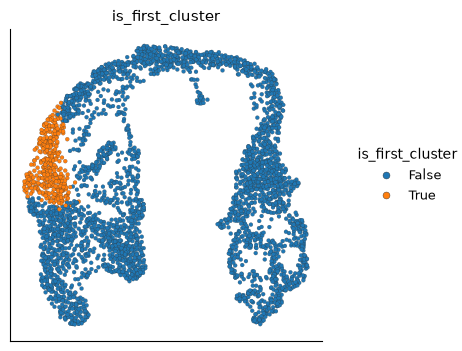

Started: 2026-10-08T11:03:13.630663Z | Wall time: 1.936 s

In [10]:
# Locate the selected cluster on the saved UMAP.
ds.plots.embedding(layout=analysis_run["umap"], color_by="is_first_cluster")

The new column marks one cluster on the same active cells used for the insert.

`fetch` returns values for the active subset (default column `I`).
`fetch_all` returns every row in the store.
With every cell active the lengths match. Pass the new Boolean column as `key` to select one
cluster without changing `I`:

In [11]:
# Compare a selected fetch with the complete metadata axis.
print(
    "fetch:",
    ds.cells.fetch("clusters", key="is_first_cluster").shape,
    "fetch_all:",
    ds.cells.fetch_all("clusters").shape,
)

fetch: (378,) fetch_all: (3696,)


Started: 2026-10-08T11:03:15.570741Z | Wall time: 0.023 s

## Select cells from metadata

`sift` returns a boolean mask over all metadata rows for one numeric range. Its bounds are
exclusive by default: the next call selects cells with more than 1,000 and fewer than 15,000
counts. Pass `keep_bounds=True` to include the endpoints.

`multi_sift` keeps rows that satisfy every range, with one lower and one upper bound per
column. `get_index_by` returns row indexes for exact categorical matches:

In [12]:
# Record the active-cell count before creating new masks.
active_before = int(ds.cells.fetch_all("I").sum())

# Select cells within the stated count range.
count_range = ds.cells.sift("RNA_nCounts", min_v=1000, max_v=15000)

# Count cells inside the count range.
{"cells in count range": int(count_range.sum())}

{'cells in count range': 3669}

Started: 2026-10-08T11:03:15.597322Z | Wall time: 0.020 s

Combine count and detected-gene limits.

In [13]:
# Apply count and detected-feature ranges together.
joint_range = ds.cells.multi_sift(
    columns=["RNA_nCounts", "RNA_nFeatures"],
    lows=[1000, 500],
    highs=[15000, 4000],
)

# Count cells satisfying both QC ranges.
{"cells in both QC ranges": int(joint_range.sum())}

{'cells in both QC ranges': 3667}

Started: 2026-10-08T11:03:15.620927Z | Wall time: 0.022 s

Find rows by their published annotation.

In [14]:
# Find the physical rows annotated as ductal cells.
ductal_rows = ds.cells.get_index_by(["Ductal"], "clusters")

# Count the rows matching the published ductal annotation.
print("Ductal cells:", int(ductal_rows.size))

# Show the active-cell count recorded before creating masks.
print("Active cells (I) before:", active_before)

# Check that creating masks left the active selection unchanged.
print("Active cells (I) after:", int(ds.cells.fetch_all("I").sum()))

Ductal cells: 916
Active cells (I) before: 3696
Active cells (I) after: 3696


Started: 2026-10-08T11:03:15.645969Z | Wall time: 0.022 s

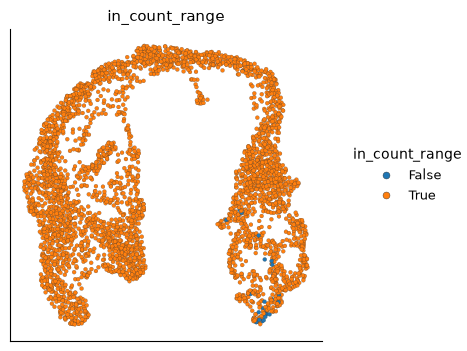

Started: 2026-10-08T11:03:15.671122Z | Wall time: 0.455 s

In [15]:
# Save the values in cell metadata using the stated selection.
ds.cells.insert(column_name="in_count_range", values=count_range, overwrite=True)

# Locate cells inside the count range on the saved UMAP.
ds.plots.embedding(layout=analysis_run["umap"], color_by="in_count_range")

These helpers return masks or indexes aligned with the metadata table.
They do not modify `I` until you explicitly insert or update a cell key.
See the `MetaData` API in [Assays and metadata API reference](/api/assays.html) for update and delete helpers.

## Optional: inspect counts and saved results

The metadata examples above are enough to read annotations and select cells. Continue here
when you need to inspect the underlying arrays or understand where analysis results are stored.

### Count matrices and normalization

Raw counts are a Zarr array (often sharded), exposed as `rawData`, a chunked array with a NumPy-like interface that streams by row.
In this store the array is at `RNA/counts`.
RNA assays also store `countsT`, a gene-major copy used by HVG and marker stages.
Routine analysis does not need to touch either array directly.

Normalized values are computed on demand through the lower-level assay `normed()` view from raw counts.
`features.normalize(cell_selection, features)` is the public persisted path and requires exact stored cell- and feature-selection references.
The direct `normed()` view follows its explicit or literal metadata indexes; in a newly created
store the physical feature `I` column is all true. Inspect the shapes without loading the
complete matrix:

In [16]:
# Inspect raw matrix dimensions without reading its values.
print("Raw shape:", ds.RNA.rawData.shape)

# Inspect normalized-view dimensions without materializing the matrix.
print("Normed shape:", ds.RNA.normed().shape)

Raw shape: (3696, 27998)
Normed shape: (3696, 27998)


Started: 2026-10-08T11:03:16.130211Z | Wall time: 0.019 s

For a worked example that reads count blocks for an external calculation, see
[](custom_analyses.ipynb).

### Inspect saved analysis results

Analysis methods return lightweight references to results stored in Zarr.
The completed `docs_default` run retained the HVG and normalization references it created.
Asking for the same normalization again reuses that result rather than recomputing:

In [17]:
# Request the saved normalization using the same exact inputs.
reused_normalized = ds.features.normalize(
    analysis_run["analysis_cell_selection"],
    analysis_run["highly_variable_features"],
)

# Check whether this request reused the saved normalization.
print("Reused:", reused_normalized == analysis_run["normalized"])

# Inspect the reference identifying the reused normalization.
reused_normalized

Reused: True


ArtifactRef(assay='RNA', kind='normalized', artifact_id='9fb6d37118da...')

Started: 2026-10-08T11:03:16.152977Z | Wall time: 0.119 s

Inspect its status and open the underlying group only when a custom method needs direct access:

In [18]:
# Inspect the saved result's completeness and provenance.
status = ds.artifacts.inspect(reused_normalized)

# Check that the saved normalization is complete.
print("Complete:", status.complete)

# Show the operation that created this artifact.
print("Operation:", status.operation)

# Show the normalization method without its internal registration details.
print("Method:", status.parameters["normalization_method"]["qualname"])

# Keep the numerical and transformation settings used for this result.
normalization_settings = {
    key: status.parameters[key]
    for key in ("size_factor", "log_transform", "renormalize_subset")
}

# Open the artifact arrays for a low-level inspection.
group = ds.artifacts.load(reused_normalized)

# List a few arrays available in the saved artifact.
print("Arrays:", list(group.array_keys())[:5])

# Inspect one normalization setting per row.
pd.Series(normalization_settings, name="value").rename_axis("setting").to_frame()

Complete: True
Operation: run_normalization
Method: norm_lib_size
Arrays: ['data', 'feature_m2', 'feature_sum']


,value
setting,
size_factor,1000.0
log_transform,True
renormalize_subset,True


Started: 2026-10-08T11:03:16.275737Z | Wall time: 0.060 s

Identical inputs and parameters {term}`reuse` a complete result.
Branching, invalidation, and lineage are covered in [](reuse_and_tracing.ipynb).

### Look inside the store

CyteArc uses [Zarr](https://zarr.readthedocs.io/en/stable/) for chunked on-disk arrays.
The store is a directory tree: counts, cell and feature attributes, and immutable artifacts live
under named groups.
Each array has its own shape, dtype, and chunk layout. CyteArc reads and writes those chunks
without loading every array in the store.

`show_zarr_tree` prints the hierarchy.
With `depth=0` you see the top-level assays and `cellData`.

In [19]:
# Locate the top-level assays, metadata and saved analyses.
ds.show_zarr_tree(depth=0)

/
├── RNA
├── artifacts
├── cellData
└── pipeline



Started: 2026-10-08T11:03:16.345524Z | Wall time: 0.036 s

Cell statistics computed from an assay are stored under `cellData` with the assay name as a prefix (`RNA_…`, `ADT_…`).

In [20]:
# Inspect the storage layout of the active-cell flag and two QC columns.
metadata_arrays = {
    name: ds.zw["cellData"][name]
    for name in ("I", "RNA_nCounts", "RNA_nFeatures")
}

# Compare array shapes, value types and chunk sizes without loading values.
pd.DataFrame({
    name: {
        "shape": array.shape,
        "dtype": str(array.dtype),
        "chunks": array.chunks,
    }
    for name, array in metadata_arrays.items()
}).T.rename_axis("cellData column")

,shape,dtype,chunks
cellData column,,,
I,"(3696,)",bool,"(100000,)"
RNA_nCounts,"(3696,)",float64,"(100000,)"
RNA_nFeatures,"(3696,)",float64,"(100000,)"


Started: 2026-10-08T11:03:16.385197Z | Wall time: 0.036 s

**The `I` column** is the default user-owned {term}`cell key`, tracking which cells are active for
live-metadata APIs. Values are boolean.
Use `snapshot_cell_selection("I")` to capture this live column before passing it to an analytical
producer. Some metadata, mapping, and export utilities still accept `cell_key` directly.

In [21]:
# Count active and inactive rows on the complete cell axis.
ds.cells.to_pandas_dataframe(["I"])["I"].value_counts()

I
True    3696
Name: count, dtype: int64

Started: 2026-10-08T11:03:16.424068Z | Wall time: 0.034 s

This store keeps every barcode active (`True`). Analytical filtering returns a separate immutable
selection artifact and leaves this column unchanged. If you deliberately author a live selection
column, its `False` rows also remain in the table rather than being deleted.

Each assay group holds `featureData` and its persisted artifacts.
Count matrices are Zarr arrays, often sharded. This store keeps RNA counts at `RNA/counts`.

In [22]:
# Inspect this part of the store hierarchy without reading counts.
ds.show_zarr_tree(start="RNA", depth=1)

/RNA
├── artifacts
│   ├── ann_index
│   ├── cluster_labels
│   ├── cluster_selection
│   ├── connectivity_map
│   ├── embedding
│   ├── embedding_initialization
│   ├── feature_scaling
│   ├── feature_selection
│   ├── feature_summary
│   ├── marker_table
│   ├── metadata_snapshot
│   ├── neighbors
│   ├── normalized
│   └── reduction
├── countSummaries
│   ├── columnPositive (27998,) int64
│   ├── featureSums
│   ├── rowPositive (3696,) int64
│   └── rowSums (3696,) float64
├── counts (3696, 27998) uint16
├── countsT (27998, 3696) uint16
└── featureData
    ├── I (27998,) bool
    ├── __cytearc_missing__highly_variable_genes (27998,) bool
    ├── dropOuts (27998,) int64
    ├── highly_variable_genes (27998,) <U5
    ├── ids (27998,) <U15
    ├── nCells (27998,) int64
    └── names (27998,) <U15

  countsT: shape=(27998, 3696), dtype=uint16, chunks=(27056, 1848), shards=(27056, 3696)
  counts: shape=(3696, 27998), dtype=uint16, chunks=(3696, 13528), shards=(3696, 40584)


Started: 2026-10-08T11:03:16.460365Z | Wall time: 0.038 s

For feature arrays, pass `start="RNA/featureData"` to the same method.

Each persisted result is an {term}`artifact`. Assay-scoped results live under
`{assay}/artifacts/{kind}/{artifact_id}`; datastore-scoped selections and integrated results live
under `artifacts/{kind}/{artifact_id}`.
The kind names the operation family and the identifier is random; CyteArc recognises an equivalent result by its recorded operation, revision, parameters, and inputs instead of recomputing it.
Nothing here encodes parameters in the path, so a second PCA at different dimensionality becomes a sibling entry rather than a new branch of the tree.

To inspect saved result groups, use `ds.show_zarr_tree(start="RNA/artifacts", depth=1)`.

[](../developers/zarr_internals.md) covers the complete on-disk layout.

### Zarr versions and storage profiles

Current CyteArc versions write new datasets as Zarr v3.
RNA assays also write a gene-major `countsT` copy next to `counts`.
The catalog dataset used here was rebuilt from its raw source with this codebase, so it already has
the current layout. Re-import older RNA stores that use Zarr v2 or lack `countsT` before analysis.

Count matrices from the writers use sharded arrays (default profile `fast_local`).
Set the profile with `CYTEARC_ZARR_PROFILE` (`fast_local` or `cloud`) or `zarrProfile=` when opening a `DataStore`.

Storage profiles and conversion belong to the physical store, while `mem_budget` and `nthreads` control execution.
See [](../concepts/memory_and_execution.md) for why RNA stores two orientations, and [](remote_stores.ipynb) for object storage and local scratch.

## Common mistakes and limitations

- Treating on-disk objects as in-memory ones: `MetaData` is not a pandas DataFrame; use `fetch, which only returns active cells; `fetch_all` returns every row, and an analysis result is a stored artifact, not a matrix to index directly.
- Expecting analysis to mutate the store: filtering never deletes rows or rewrites live `I`, and saved artifacts are immutable products of analysis methods, not groups to edit by hand.
- Opening an older RNA store (Zarr v2, or without the `countsT` copy) in a current CyteArc version; re-import the store before analysis.


Metadata changes and artifacts are written into the Zarr store.
Low-level layout details intended for contributors remain in [](../developers/zarr_internals.md).